In [8]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from scipy.stats import linregress
#import cartopy.crs as ccrs
import matplotlib.cm as cm
from scipy.ndimage.filters import gaussian_filter

/tmp/ipykernel_11405/4229129016.py:8: DeprecationWarning: Please import `gaussian_filter` from the `scipy.ndimage` namespace; the `scipy.ndimage.filters` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.filters import gaussian_filter


In [9]:
ua2016 = pd.read_csv("./Data/2016/csv/Unfallorte_2016_LinRef.txt", sep=";", decimal=",")
ua2017 = pd.read_csv("./Data/2017/csv/Unfallorte2017_LinRef.txt", sep=";", decimal=",")
ua2018 = pd.read_csv("./Data/2018/csv/Unfallorte2018_LinRef.txt", sep=";", decimal=",")
ua2019 = pd.read_csv("./Data/2019/csv/Unfallorte2019_LinRef.txt", sep=";", decimal=",")
ua2020 = pd.read_csv("./Data/2020/csv/Unfallorte2020_LinRef.csv", sep=";", decimal=",")
ua2021 = pd.read_csv("./Data/2021/csv/Unfallorte_2021_LinRef.txt", sep=";", decimal=",")
ua2022 = pd.read_csv("./Data/2022/csv/Unfallorte2022_LinRef.csv", sep=";", decimal=",")
ua2023 = pd.read_csv("./Data/2023/csv/Unfallorte2023_LinRef.csv", sep=";", decimal=",")

ua_leip_20162020 = pd.read_csv("Data/unfallatlasleipzig20162020.csv")

einwohn_leip = pd.read_csv("./Data/Leipzig/Bevölkerungsbestand_Einwohner.csv", sep=",")

einwohn_sax = pd.read_csv("./Data/Sachsen/Einwohner_Sachsen.csv", sep=";")


/tmp/ipykernel_11405/832639538.py:2: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  ua2017 = pd.read_csv("./Data/2017/csv/Unfallorte2017_LinRef.txt", sep=";", decimal=",")
/tmp/ipykernel_11405/832639538.py:6: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  ua2021 = pd.read_csv("./Data/2021/csv/Unfallorte_2021_LinRef.txt", sep=";", decimal=",")
/tmp/ipykernel_11405/832639538.py:7: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  ua2022 = pd.read_csv("./Data/2022/csv/Unfallorte2022_LinRef.csv", sep=";", decimal=",")
/tmp/ipykernel_11405/832639538.py:8: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  ua2023 = pd.read_csv("./Data/2023/csv/Unfallorte2023_LinRef.csv", sep=";", decimal=",")


In [10]:
einwohn_sax = einwohn_sax.rename(columns = {"Kreis":"KREIS"})

In [11]:
leip_str_sh = gpd.read_file("./Data/Leipzig/Radwege/shape/roads.shp")

<Axes: >

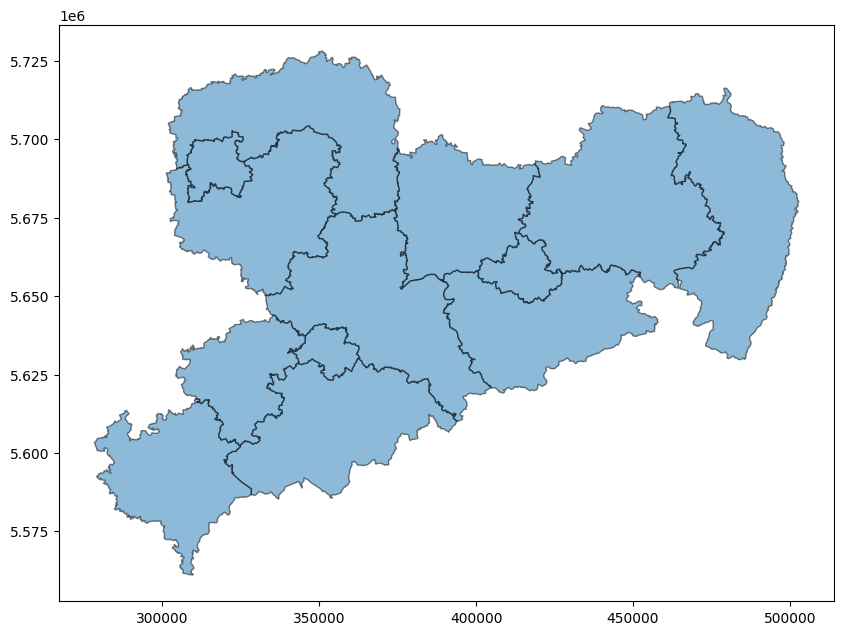

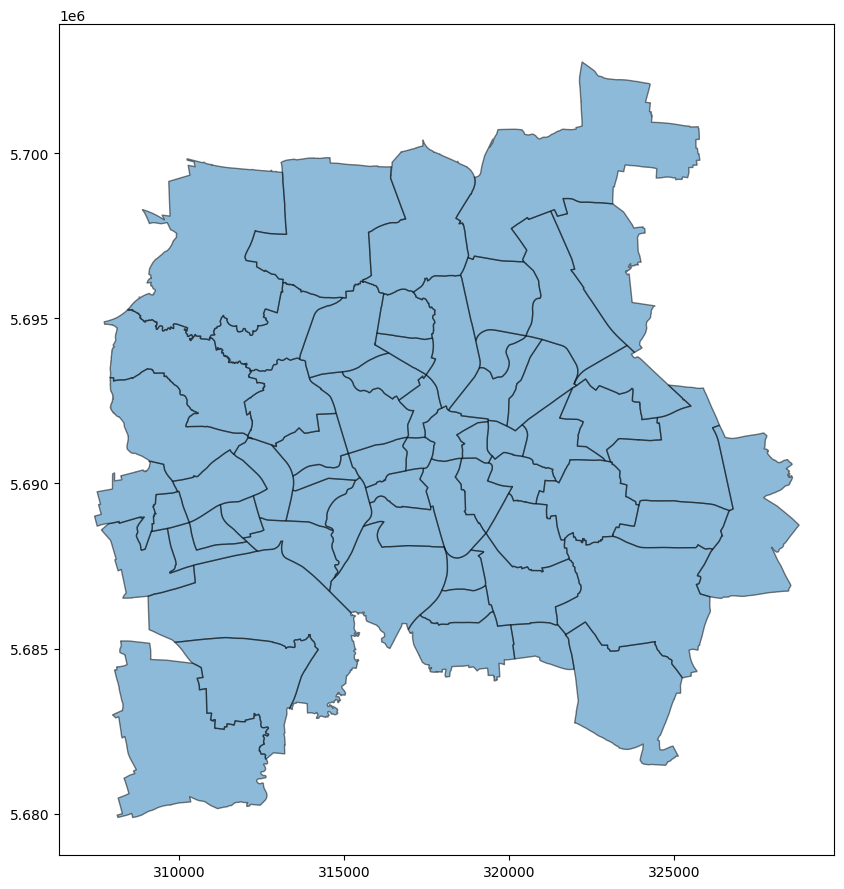

In [12]:
#Shapefiles von Sachsen und Leipzig einlesen
# https://data-seattlecitygis.opendata.arcgis.com/datasets/SeattleCityGIS::neighborhood-map-atlas-districts/about
sax_df = gpd.read_file("./Data/Sachsen/kreis.shp")
leip_df = gpd.read_file("./Data/Leipzig/ot.shp")

sax_df.plot(figsize=(10,15), alpha=0.5, edgecolor='k')
leip_df.plot(figsize=(10,15), alpha=0.5, edgecolor='k')

In [13]:
sax_df.to_crs(epsg=4269,inplace=True)

In [14]:
leip_df.to_crs(epsg=4269,inplace=True)

In [15]:
#Geometry Spalte erzeugen
    #TODO für alle Jahre durchführen!
#ua_leip_20162020["geometry"] = ua_leip_20162020["XGCSWGS84"]

ua_leip_20162020 = gpd.GeoDataFrame(
    ua_leip_20162020,
    geometry = gpd.points_from_xy(
        x = ua_leip_20162020.XGCSWGS84,
        y = ua_leip_20162020.YGCSWGS84,
        crs = 'EPSG:4326', # or: crs = pyproj.CRS.from_user_input(4326)
    )

)

ua2016 = gpd.GeoDataFrame(
    ua2016,
    geometry = gpd.points_from_xy(
        x = ua2016.XGCSWGS84,
        y = ua2016.YGCSWGS84,
        crs = 'EPSG:4326', # or: crs = pyproj.CRS.from_user_input(4326)
    )

)

ua2017 = gpd.GeoDataFrame(
    ua2017,
    geometry = gpd.points_from_xy(
        x = ua2017.XGCSWGS84,
        y = ua2017.YGCSWGS84,
        crs = 'EPSG:4326', # or: crs = pyproj.CRS.from_user_input(4326)
    )

)

ua2018 = gpd.GeoDataFrame(
    ua2018,
    geometry = gpd.points_from_xy(
        x = ua2018.XGCSWGS84,
        y = ua2018.YGCSWGS84,
        crs = 'EPSG:4326', # or: crs = pyproj.CRS.from_user_input(4326)
    )

)

ua2019 = gpd.GeoDataFrame(
    ua2019,
    geometry = gpd.points_from_xy(
        x = ua2019.XGCSWGS84,
        y = ua2019.YGCSWGS84,
        crs = 'EPSG:4326', # or: crs = pyproj.CRS.from_user_input(4326)
    )

)

ua2020 = gpd.GeoDataFrame(
    ua2020,
    geometry = gpd.points_from_xy(
        x = ua2020.XGCSWGS84,
        y = ua2020.YGCSWGS84,
        crs = 'EPSG:4326', # or: crs = pyproj.CRS.from_user_input(4326)
    )

)

ua2021 = gpd.GeoDataFrame(
    ua2021,
    geometry = gpd.points_from_xy(
        x = ua2021.XGCSWGS84,
        y = ua2021.YGCSWGS84,
        crs = 'EPSG:4326', # or: crs = pyproj.CRS.from_user_input(4326)
    )

)

ua2022 = gpd.GeoDataFrame(
    ua2022,
    geometry = gpd.points_from_xy(
        x = ua2022.XGCSWGS84,
        y = ua2022.YGCSWGS84,
        crs = 'EPSG:4326', # or: crs = pyproj.CRS.from_user_input(4326)
    )

)

ua2023 = gpd.GeoDataFrame(
    ua2023,
    geometry = gpd.points_from_xy(
        x = ua2023.XGCSWGS84,
        y = ua2023.YGCSWGS84,
        crs = 'EPSG:4326', # or: crs = pyproj.CRS.from_user_input(4326)
    )

)

In [16]:
ua2016 = ua2016.drop("FID", axis=1)
ua2017 = ua2017.drop("UIDENTSTLA", axis=1)
ua2017 = ua2017.rename(columns = {"LICHT":"ULICHTVERH"})
ua2018 = ua2018.rename(columns = {"OBJECTID_1":"OBJECTID"})

ua2020 = ua2020.drop("UIDENTSTLAE", axis=1)
ua2021 = ua2021.drop("UIDENTSTLAE", axis=1)
ua2021 = ua2021.rename(columns = {"OID_":"OBJECTID"})
ua2022 = ua2022.drop("UIDENTSTLAE", axis=1)
ua2023 = ua2023.drop("UIDENTSTLAE", axis=1)
ua2023 = ua2023.rename(columns = {"OID_":"OBJECTID"})
ua2023 = ua2023.drop("PLST", axis=1)

ua2016 = ua2016.drop("IstGkfz", axis=1)
ua2018 = ua2018.drop("IstGkfz", axis=1)
ua2019 = ua2019.drop("IstGkfz", axis=1)
ua2020 = ua2020.drop("IstGkfz", axis=1)
ua2021 = ua2021.drop("IstGkfz", axis=1)
ua2022 = ua2022.drop("IstGkfz", axis=1)
ua2023 = ua2023.drop("IstGkfz", axis=1)

ua2016 = ua2016.rename(columns = {"IstStrasse":"STRZUSTAND"})
ua2021 = ua2021.rename(columns = {"IstStrassenzustand":"STRZUSTAND"})
ua2022 = ua2022.rename(columns = {"IstStrassenzustand":"STRZUSTAND"})
ua2023 = ua2023.rename(columns = {"IstStrassenzustand":"STRZUSTAND"})

ua2019 = ua2019.rename(columns = {"IstSonstige":"IstSonstig"})
ua2020 = ua2020.rename(columns = {"IstSonstige":"IstSonstig"})
ua2021 = ua2021.rename(columns = {"IstSonstige":"IstSonstig"})
ua2022 = ua2022.rename(columns = {"IstSonstige":"IstSonstig"})
ua2023 = ua2023.rename(columns = {"IstSonstige":"IstSonstig"})


ua2016 = ua2016.loc[:, ["OBJECTID","ULAND","UREGBEZ","UKREIS","UGEMEINDE","UJAHR","UMONAT","USTUNDE","UWOCHENTAG","UKATEGORIE","UART","UTYP1","ULICHTVERH","IstRad","IstPKW","IstFuss","IstKrad","IstSonstig","STRZUSTAND","LINREFX","LINREFY","XGCSWGS84","YGCSWGS84","geometry"]]
ua2017 = ua2017.loc[:, ["OBJECTID","ULAND","UREGBEZ","UKREIS","UGEMEINDE","UJAHR","UMONAT","USTUNDE","UWOCHENTAG","UKATEGORIE","UART","UTYP1","ULICHTVERH","IstRad","IstPKW","IstFuss","IstKrad","IstSonstig","STRZUSTAND","LINREFX","LINREFY","XGCSWGS84","YGCSWGS84","geometry"]]
ua2018 = ua2018.loc[:, ["OBJECTID","ULAND","UREGBEZ","UKREIS","UGEMEINDE","UJAHR","UMONAT","USTUNDE","UWOCHENTAG","UKATEGORIE","UART","UTYP1","ULICHTVERH","IstRad","IstPKW","IstFuss","IstKrad","IstSonstig","STRZUSTAND","LINREFX","LINREFY","XGCSWGS84","YGCSWGS84","geometry"]]
ua2019 = ua2019.loc[:, ["OBJECTID","ULAND","UREGBEZ","UKREIS","UGEMEINDE","UJAHR","UMONAT","USTUNDE","UWOCHENTAG","UKATEGORIE","UART","UTYP1","ULICHTVERH","IstRad","IstPKW","IstFuss","IstKrad","IstSonstig","STRZUSTAND","LINREFX","LINREFY","XGCSWGS84","YGCSWGS84","geometry"]]
ua2020 = ua2020.loc[:, ["OBJECTID","ULAND","UREGBEZ","UKREIS","UGEMEINDE","UJAHR","UMONAT","USTUNDE","UWOCHENTAG","UKATEGORIE","UART","UTYP1","ULICHTVERH","IstRad","IstPKW","IstFuss","IstKrad","IstSonstig","STRZUSTAND","LINREFX","LINREFY","XGCSWGS84","YGCSWGS84","geometry"]]
ua2021 = ua2021.loc[:, ["OBJECTID","ULAND","UREGBEZ","UKREIS","UGEMEINDE","UJAHR","UMONAT","USTUNDE","UWOCHENTAG","UKATEGORIE","UART","UTYP1","ULICHTVERH","IstRad","IstPKW","IstFuss","IstKrad","IstSonstig","STRZUSTAND","LINREFX","LINREFY","XGCSWGS84","YGCSWGS84","geometry"]]
ua2022 = ua2022.loc[:, ["OBJECTID","ULAND","UREGBEZ","UKREIS","UGEMEINDE","UJAHR","UMONAT","USTUNDE","UWOCHENTAG","UKATEGORIE","UART","UTYP1","ULICHTVERH","IstRad","IstPKW","IstFuss","IstKrad","IstSonstig","STRZUSTAND","LINREFX","LINREFY","XGCSWGS84","YGCSWGS84","geometry"]]
ua2023 = ua2023.loc[:, ["OBJECTID","ULAND","UREGBEZ","UKREIS","UGEMEINDE","UJAHR","UMONAT","USTUNDE","UWOCHENTAG","UKATEGORIE","UART","UTYP1","ULICHTVERH","IstRad","IstPKW","IstFuss","IstKrad","IstSonstig","STRZUSTAND","LINREFX","LINREFY","XGCSWGS84","YGCSWGS84","geometry"]]


In [17]:
frames = [ua2016, ua2017, ua2018, ua2019, ua2020, ua2021, ua2022, ua2023]

result = pd.concat(frames)
result = result.loc[(result["ULAND"]==14) & (result["IstRad"]==1)]
result_leip = result.loc[(result["ULAND"]==14) & (result["IstRad"]==1) & (result["UREGBEZ"]==7) & (result["UKREIS"]==13)]


In [18]:
einwohn_leip = einwohn_leip.rename(columns = {"Gebiet":"Name"})
einwohn_leip_gsmt = einwohn_leip.loc[einwohn_leip["Sachmerkmal"]=="Einwohner insgesamt"]
shape_einwohn_leip = leip_df.merge(einwohn_leip_gsmt, on="Name", how="left")

In [19]:
# uf_pro_ST_raw = ua_leip_20162020.sjoin(leip_df, how="inner", predicate='intersects')
# uf_pro_ST = uf_pro_ST_raw["Name"].value_counts()

In [20]:
# shape_einwohn_leip_uf = shape_einwohn_leip.merge(uf_pro_ST, on="Name", how="left")
# shape_einwohn_leip_uf["Uf_Ew"] = shape_einwohn_leip_uf["count"]/shape_einwohn_leip_uf["2018"]
# shape_einwohn_leip_uf["Uf_Ew1000"] = shape_einwohn_leip_uf["count"]/shape_einwohn_leip_uf["2018"]*1000

In [21]:
uf_pro_ST_raw_gsmt = result_leip.sjoin(leip_df, how="inner", predicate='intersects')
uf_pro_ST_gsmt = uf_pro_ST_raw_gsmt["Name"].value_counts()

shape_einwohn_leip_uf_gsmt = shape_einwohn_leip.merge(uf_pro_ST_gsmt, on="Name", how="left")
shape_einwohn_leip_uf_gsmt["Uf_Ew"] = shape_einwohn_leip_uf_gsmt["count"] / shape_einwohn_leip_uf_gsmt["2020"]
shape_einwohn_leip_uf_gsmt["Uf_Ew1000"] = shape_einwohn_leip_uf_gsmt["count"] / shape_einwohn_leip_uf_gsmt["2020"] * 1000

/home/fabian/PycharmProjects/Fedora/.venv/lib/python3.13/site-packages/geopandas/geodataframe.py:2560: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4326
Right CRS: EPSG:4269

  return geopandas.sjoin(


In [22]:
shape_einwohn_sax = sax_df.merge(einwohn_sax, on="KREIS", how="left")

uf_pro_Kreis_raw = result.sjoin(sax_df, how="inner", predicate='intersects')
uf_pro_Kreis = uf_pro_Kreis_raw["KREIS"].value_counts()

shape_einwohn_sax_uf = shape_einwohn_sax.merge(uf_pro_Kreis, on="KREIS", how="left")
shape_einwohn_sax_uf["Uf_Ew"] = shape_einwohn_sax_uf["count"] / shape_einwohn_sax_uf["2023"]
shape_einwohn_sax_uf["Uf_Ew1000"] = shape_einwohn_sax_uf["count"] / shape_einwohn_sax_uf["2023"] * 1000

/home/fabian/PycharmProjects/Fedora/.venv/lib/python3.13/site-packages/geopandas/geodataframe.py:2560: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4326
Right CRS: EPSG:4269

  return geopandas.sjoin(


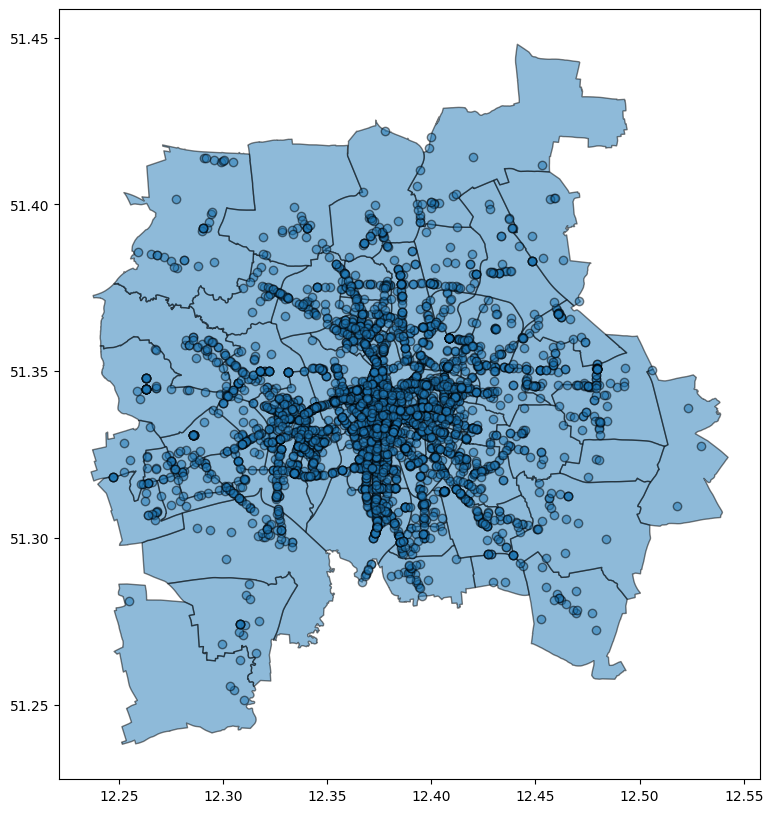

In [23]:
fig, ax = plt.subplots(figsize=(10, 10))
leip_df.plot(ax=ax, alpha=0.5, edgecolor='k')
ua_leip_20162020.geometry.plot(ax=ax, alpha=0.5, edgecolor='k')
plt.show()

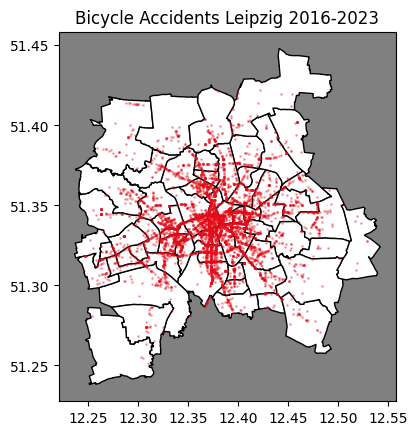

In [24]:
base = shape_einwohn_leip.plot(color='white', edgecolor='black')
base.set_facecolor("grey")
base.set_title('Bicycle Accidents Leipzig 2016-2023')

result_leip.plot(ax=base, marker='o', color='#e40d1a', markersize=1, alpha=0.3);

#plt.savefig("./plots/1.png")

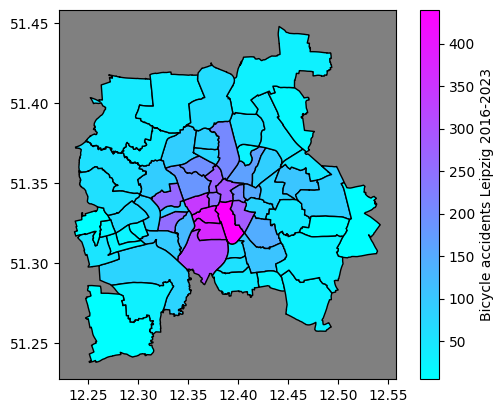

In [25]:
# Plot population estimates with an accurate legend

base = shape_einwohn_leip_uf_gsmt.plot(

    column="count",

    legend=True,

    legend_kwds={"label": "Bicycle accidents Leipzig 2016-2023"},

    cmap="cool",

    edgecolor='black'
);

base.set_facecolor("grey")

#plt.savefig("./plots/2.png")

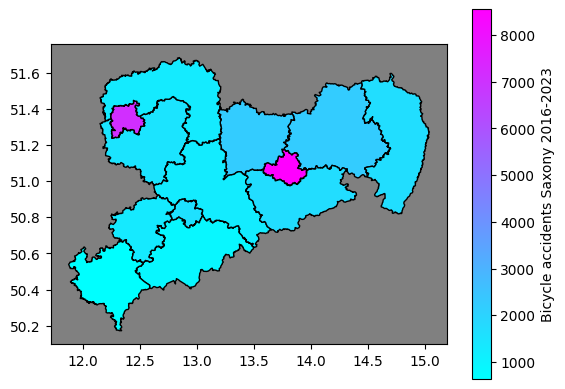

In [26]:
base = shape_einwohn_sax_uf.plot(

    column="count",

    legend=True,

    legend_kwds={"label": "Bicycle accidents Saxony 2016-2023"},

    cmap="cool",

    edgecolor='black'
);

base.set_facecolor("grey")
#plt.savefig("./plots/3.png")

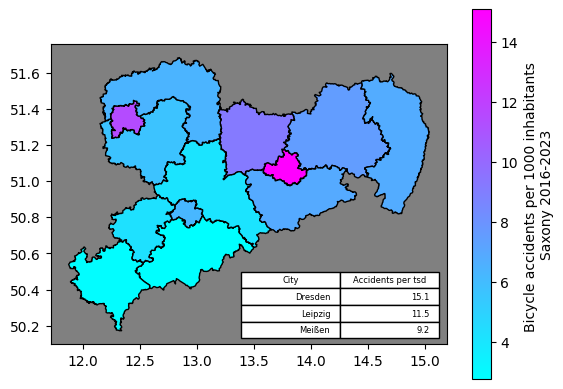

In [28]:
base = shape_einwohn_sax_uf.plot(

    column="Uf_Ew1000",

    legend=True,

    legend_kwds={"label": "Bicycle accidents per 1000 inhabitants \nSaxony 2016-2023"},

    cmap="cool",

    edgecolor='black'

);
#base.annotate('local max', xy=(12.3, 51.35), xytext=(13.5, 50.2), arrowprops=dict(facecolor='white', shrink=0.05, alpha=0.8),)

text=[["Dresden","15.1" ],["Leipzig","11.5"],[u"Meißen", "9.2"]]
colLabels = ["City", u"Accidents per tsd"]
tab = base.table(cellText=text, colLabels=colLabels, colWidths = [0.25,0.25],    loc='lower right')
base.set_facecolor("grey")
plt.savefig("./plots/4.png")